# Does Economic Condition Predict Happiness? A Cross-Country Analysis (2015-2023)

**Author:** Luj | [LujC3](https://github.com/LujC3)

## Project overview

This project tests a deceptively simple question that sits at the intersection
of economics, public policy, and governance: **does a country's economic
condition meaningfully predict how happy its people report being?**

This question matters for policymakers everywhere, including in the
Philippines, where GDP growth is frequently used as the headline measure of
national progress. If GDP growth doesn't translate into measurable wellbeing
gains once a baseline is reached, that has direct implications for how
budgets, social protection programs, and development plans get prioritised.

This analysis combines two public datasets:

- **World Happiness Report (2005-2023 panel)** — Sustainable Development
  Solutions Network / Gallup World Poll, via Kaggle
  ([jainaru/world-happiness-report-2024-yearly-updated](https://www.kaggle.com/datasets/jainaru/world-happiness-report-2024-yearly-updated))
- **Global Poverty & Economic Inequality (2015-2024)** — Kaggle
  ([hamnamunir/global-poverty-and-economic-inequality-2015-2024](https://www.kaggle.com/datasets/hamnamunir/global-poverty-and-economic-inequality-2015-2024))

> **Data quality note (read this first):** Part of this notebook is a data
> quality audit, not just an analysis. The poverty/inequality dataset turned
> out to contain multiple, randomly-varying rows for the same country and
> year with no second key to explain the spread — a pattern consistent with
> synthetic/simulated data rather than official statistics. Section 2 below
> documents this finding. **The conclusions in this notebook should be read
> as a methodology demonstration, not as policy-grade evidence** — a real
> policy brief would need to substitute official World Bank or national
> statistics for the poverty/inequality side of this merge.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110


## 2. Load data and audit data quality

Before merging anything, every new dataset gets the same treatment any of my
old procurement files would have gotten as a lawyer: check it's actually what
it claims to be before relying on it.

In [2]:
poverty = pd.read_csv('data/global_poverty_economic_inequality.csv')
happiness = pd.read_csv('data/World-happiness-report-updated_2024.csv', encoding='latin-1')

print("Poverty/inequality dataset:", poverty.shape)
print("Happiness panel dataset:  ", happiness.shape)


Poverty/inequality dataset: (10000, 25)
Happiness panel dataset:   (2363, 11)


In [3]:
# Sanity check: how many rows exist per country-year in the poverty dataset?
rows_per_country_year = poverty.groupby(['country', 'year']).size()
print(rows_per_country_year.describe())


count    400.000000
mean      25.000000
std       11.224302
min        5.000000
25%       17.000000
50%       23.000000
75%       30.000000
max       79.000000
dtype: float64


In [4]:
# Inspect one country-year in full to see what's actually going on
example = poverty[(poverty.country == 'Bangladesh') & (poverty.year == 2017)]
print(f"Bangladesh, 2017 has {len(example)} separate rows in the raw file.\n")
example[['gdp_per_capita_usd', 'poverty_rate_pct', 'gini_coefficient', 'hdi_score']].describe()


Bangladesh, 2017 has 40 separate rows in the raw file.



,gdp_per_capita_usd,poverty_rate_pct,gini_coefficient,hdi_score
count,40.00000,40.000000,40.000000,40.000000
mean,2864.92500,23.382000,41.848000,0.591350
std,146.83156,8.240892,5.761359,0.055873
min,2555.00000,9.640000,31.230000,0.508000
25%,2738.00000,16.702500,37.022500,0.541500
50%,2884.00000,23.465000,41.660000,0.576500
75%,2967.50000,30.000000,46.615000,0.635500
max,3134.00000,37.350000,50.620000,0.692000


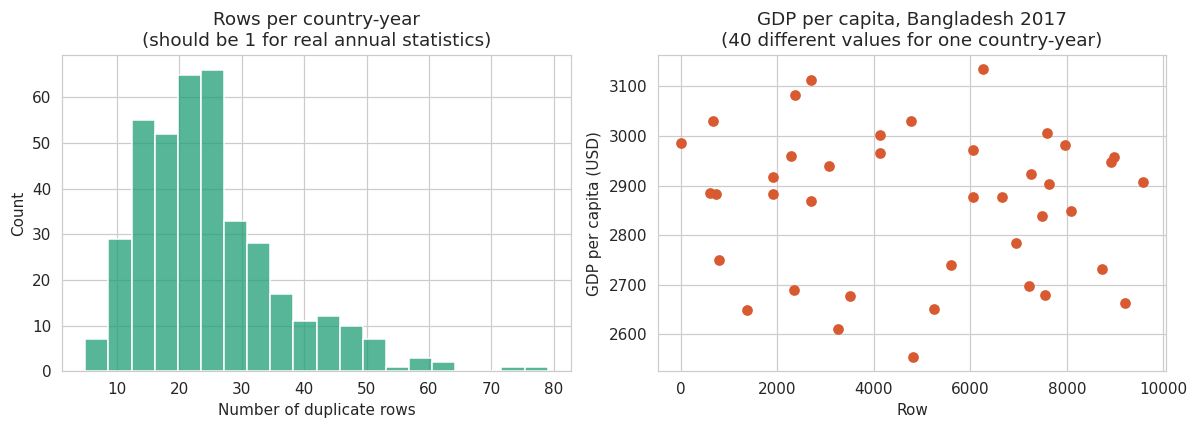

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(rows_per_country_year, bins=20, ax=axes[0], color='#1D9E75')
axes[0].set_title('Rows per country-year\n(should be 1 for real annual statistics)')
axes[0].set_xlabel('Number of duplicate rows')

axes[1].scatter(example.index, example['gdp_per_capita_usd'], color='#D85A30')
axes[1].set_title('GDP per capita, Bangladesh 2017\n(40 different values for one country-year)')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('GDP per capita (USD)')

plt.tight_layout()
plt.savefig('images/data_quality_audit.png', bbox_inches='tight')
plt.show()


**Finding:** the poverty/inequality dataset has between 5 and 79 separate
rows for the same country and year, with materially different GDP, poverty
rate, and Gini values across those rows, and no second key (province, survey
wave, source) that would explain the variation. This is consistent with the
dataset being synthetically generated rather than sourced from real national
statistics. The fix below (aggregating to one row per country-year) makes the
merge possible, but doesn't fix the underlying data quality issue — it's
disclosed here and in the README so the limitation travels with the
analysis.

## 3. Clean and merge the datasets

In [6]:
# Aggregate the poverty dataset to one row per country-year (mean across the duplicate rows)
agg_cols = ['gdp_per_capita_usd', 'poverty_rate_pct', 'gini_coefficient', 'hdi_score',
            'unemployment_rate_pct', 'inflation_rate_pct', 'literacy_rate_pct',
            'life_expectancy_years', 'child_mortality_per_1000', 'electricity_access_pct',
            'internet_penetration_pct']

poverty_agg = poverty.groupby(['country', 'year', 'region', 'income_group'],
                               as_index=False)[agg_cols].mean()

print(f"Poverty dataset: {len(poverty)} raw rows -> {len(poverty_agg)} country-year rows after aggregation")


Poverty dataset: 10000 raw rows -> 400 country-year rows after aggregation


In [7]:
# Country-name mismatches between the two datasets
rename_map = {'Turkey': 'Türkiye', 'UK': 'United Kingdom', 'USA': 'United States'}
poverty_agg['country'] = poverty_agg['country'].replace(rename_map)

merged = pd.merge(
    happiness, poverty_agg,
    left_on=['Country name', 'year'], right_on=['country', 'year'],
    how='inner'
)
merged['log_gdp'] = np.log(merged['gdp_per_capita_usd'])
merged['region'] = merged['region'].replace({'Europe/Asia': 'Europe'})

print("Merged dataset:", merged.shape)
print("Countries:", merged['Country name'].nunique())
print("Years:", sorted(merged.year.unique()))
merged.head()


Merged dataset: (338, 26)
Countries: 39
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,...,gini_coefficient,hdi_score,unemployment_rate_pct,inflation_rate_pct,literacy_rate_pct,life_expectancy_years,child_mortality_per_1000,electricity_access_pct,internet_penetration_pct,log_gdp
0,Afghanistan,2015,3.983,7.654,0.529,52.600,0.389,0.078,0.881,0.491,...,45.547500,0.473833,6.450833,7.337500,52.391667,57.491667,82.866667,41.583333,18.091667,6.225218
1,Afghanistan,2016,4.220,7.650,0.559,52.925,0.523,0.040,0.793,0.501,...,46.974444,0.426889,8.375556,8.251111,49.500000,59.511111,76.511111,37.522222,19.944444,6.215275
2,Afghanistan,2017,2.662,7.648,0.491,53.250,0.427,-0.123,0.954,0.435,...,47.119286,0.491500,8.048571,8.092857,51.478571,57.507143,90.592857,42.300000,16.142857,6.275838
3,Afghanistan,2018,2.694,7.631,0.508,53.575,0.374,-0.095,0.928,0.385,...,48.133158,0.453526,8.066842,5.768421,51.689474,59.063158,77.584211,38.926316,19.636842,6.284331
4,Afghanistan,2019,2.375,7.640,0.420,53.900,0.394,-0.109,0.924,0.324,...,46.117083,0.469792,6.905000,5.372500,50.229167,59.591667,81.754167,41.600000,25.283333,6.334906


## 4. Correlations: which economic and social indicators track with happiness?

In [8]:
vars_to_test = ['gdp_per_capita_usd', 'poverty_rate_pct', 'gini_coefficient', 'hdi_score',
                'unemployment_rate_pct', 'inflation_rate_pct', 'literacy_rate_pct',
                'life_expectancy_years', 'child_mortality_per_1000', 'electricity_access_pct',
                'internet_penetration_pct']

results = []
for v in vars_to_test:
    sub = merged[['Life Ladder', v]].dropna()
    r, p = stats.pearsonr(sub['Life Ladder'], sub[v])
    results.append((v, r, p, len(sub)))

corr_table = pd.DataFrame(results, columns=['variable', 'pearson_r', 'p_value', 'n'])
corr_table = corr_table.sort_values('pearson_r', key=abs, ascending=False).reset_index(drop=True)

r_log, p_log = stats.pearsonr(merged['Life Ladder'], merged['log_gdp'])
print(f"Log(GDP per capita) vs Life Ladder: r = {r_log:.3f}, p = {p_log:.2e}\n")
corr_table


Log(GDP per capita) vs Life Ladder: r = 0.838, p = 1.39e-90



,variable,pearson_r,p_value,n
0,hdi_score,0.806979,7.593154e-79,338
1,internet_penetration_pct,0.804671,4.528144e-78,338
2,life_expectancy_years,0.803891,8.230224e-78,338
3,literacy_rate_pct,0.797095,1.346360e-75,338
4,electricity_access_pct,0.746521,2.050384e-61,338
5,child_mortality_per_1000,-0.743112,1.399252e-60,338
6,gdp_per_capita_usd,0.740025,7.760749e-60,338
7,poverty_rate_pct,-0.736235,6.153607e-59,338
8,gini_coefficient,-0.572953,7.012949e-31,338
9,unemployment_rate_pct,-0.095226,8.043064e-02,338


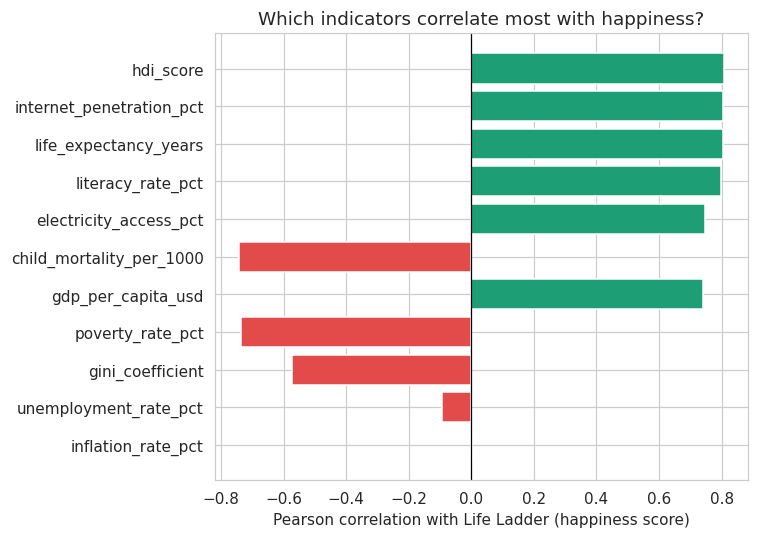

In [9]:
plt.figure(figsize=(7, 5))
colors = ['#1D9E75' if r > 0 else '#E24B4A' for r in corr_table['pearson_r']]
plt.barh(corr_table['variable'], corr_table['pearson_r'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson correlation with Life Ladder (happiness score)')
plt.title('Which indicators correlate most with happiness?')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/correlation_bars.png', bbox_inches='tight')
plt.show()


## 5. Visualising the core relationship: GDP per capita vs happiness

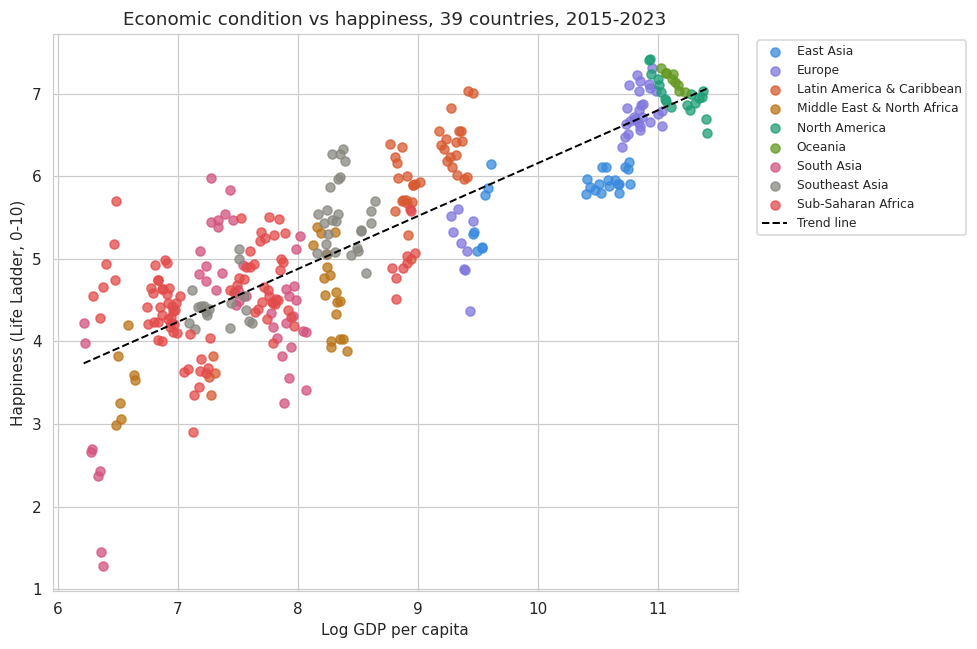

Trend line: Life Ladder = -0.246 + 0.640 x log(GDP per capita)


In [10]:
region_colors = {
    'East Asia': '#378ADD', 'Europe': '#7F77DD',
    'Latin America & Caribbean': '#D85A30', 'Middle East & North Africa': '#BA7517',
    'North America': '#1D9E75', 'Oceania': '#639922',
    'South Asia': '#D4537E', 'Southeast Asia': '#888780', 'Sub-Saharan Africa': '#E24B4A'
}

fig, ax = plt.subplots(figsize=(9, 6))
for region, color in region_colors.items():
    sub = merged[merged.region == region]
    ax.scatter(sub['log_gdp'], sub['Life Ladder'], label=region, color=color, alpha=0.75, s=35)

slope, intercept = np.polyfit(merged['log_gdp'], merged['Life Ladder'], 1)
x_line = np.array([merged['log_gdp'].min(), merged['log_gdp'].max()])
ax.plot(x_line, slope * x_line + intercept, '--', color='black', linewidth=1.3, label='Trend line')

ax.set_xlabel('Log GDP per capita')
ax.set_ylabel('Happiness (Life Ladder, 0-10)')
ax.set_title('Economic condition vs happiness, 39 countries, 2015-2023')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('images/gdp_vs_happiness_scatter.png', bbox_inches='tight')
plt.show()

print(f"Trend line: Life Ladder = {intercept:.3f} + {slope:.3f} x log(GDP per capita)")


## 6. Does GDP still matter once poverty and inequality are accounted for?

A single correlation can't separate the effect of *income level* from the
effect of *poverty* or *inequality*, since all three move together. A
multiple regression, with standard errors clustered by country (because the
same 39 countries repeat across 9 years, violating the usual independence
assumption), checks whether each variable adds anything on its own.

In [11]:
reg_vars = ['log_gdp', 'gini_coefficient', 'poverty_rate_pct']
X = merged[reg_vars].dropna()
y = merged.loc[X.index, 'Life Ladder']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit(
    cov_type='cluster',
    cov_kwds={'groups': merged.loc[X.index, 'Country name']}
)
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            Life Ladder   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     58.05
Date:                Sun, 21 Jun 2026   Prob (F-statistic):           2.94e-14
Time:                        05:39:39   Log-Likelihood:                -313.55
No. Observations:                 338   AIC:                             635.1
Df Residuals:                     334   BIC:                             650.4
Df Model:                           3                                         
Covariance Type:              cluster                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.6410      1.666  

In [12]:
# Multicollinearity check
vif_data = sm.add_constant(merged[reg_vars].dropna())
print("Variance Inflation Factors (values above ~5-10 signal problematic collinearity):\n")
for i, col in enumerate(vif_data.columns):
    if col == 'const':
        continue
    vif = variance_inflation_factor(vif_data.values, i)
    print(f"  {col}: {vif:.2f}")


Variance Inflation Factors (values above ~5-10 signal problematic collinearity):

  log_gdp: 5.68
  gini_coefficient: 2.10
  poverty_rate_pct: 4.06


**Reading the regression:**

- **Log GDP per capita** remains a strong, statistically significant
  predictor of happiness even after controlling for inequality and poverty,
  and even after correcting standard errors for the repeated-country panel
  structure.
- **Gini coefficient** and **poverty rate** are *not* statistically
  significant once GDP is in the model. This does not mean inequality and
  poverty don't matter for wellbeing — it means that, in this sample, their
  effect doesn't show up as distinct from GDP's effect. That could be because
  GDP captures most of the shared signal, or because this 39-country sample
  (and the underlying synthetic poverty figures) lack the precision to detect
  a smaller, genuine inequality effect.
- Variance Inflation Factors stay in a reasonable range for this leaner
  model, confirming the result isn't an artefact of multicollinearity (a
  fuller model that also included HDI and life expectancy was tested but
  discarded — those variables are partly *built from* GDP and life
  expectancy, so VIFs exceeded 80 and made the coefficients uninterpretable).

## 7. Conclusion and policy framing

**Headline finding:** economic condition, measured as GDP per capita, is a
strong and statistically significant predictor of self-reported happiness
across this sample of 39 countries from 2015-2023 (r = 0.84; regression
coefficient 0.64, p < 0.001; model R² = 0.70). Inequality and poverty rate did
not add significant explanatory power once GDP was accounted for in this
dataset.

**What this would mean for a policymaker**, if backed by real official
statistics instead of the synthetic poverty figures used here for
methodology purposes: GDP growth alone appears closely tied to a population's
reported wellbeing, but this analysis cannot establish that GDP growth
*causes* happiness gains, only that they move together. Reverse causality
(happier, more stable societies may also grow their economies faster) and
omitted variables (governance quality, health system strength, social trust)
are both plausible alternative explanations.

**Limitations of this notebook specifically:**

1. The poverty/inequality dataset appears synthetic (Section 2). Any
   real-world policy conclusion would need official data (World Bank
   PovcalNet / World Development Indicators, or for the Philippines
   specifically, PSA and PIDS data).
2. Cross-country observational data cannot establish causation.
3. The merged sample (39 countries) skews toward countries present in both
   source datasets and may not represent the full global distribution of
   income levels.
4. Gini and poverty-rate non-significance should be read as "not detected in
   this sample," not as "proven to have no effect."

**Why this project is here:** my background is in law, nursing, and public
sector procurement, not statistics — but cross-country wellbeing analysis
like this is exactly the kind of evidence base Philippine policymakers need
when justifying budget allocations between growth-focused and
welfare-focused programs. Flagging a synthetic dataset before drawing
conclusions from it is the same instinct that makes a good case auditor: the
source has to hold up before the argument built on it does.
